## BƯỚC 1: Setup môi trường

### 1.1 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Khai báo đường dẫn gốc và tạo cấu trúc thư mục

In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/waste-classification"

folders = [
    "data/raw", "data/processed", "data/train_test_split",
    "models", "notebooks", "src", "assets"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print("Đã tạo xong cấu trúc thư mục!")

Đã tạo xong cấu trúc thư mục!


### 1.3 Cài đặt thư viện bổ sung

In [ ]:
!pip install -q kaggle split-folders

### 1.4 Kiểm tra GPU

In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## BƯỚC 2: Tải và khám phá dữ liệu (EDA)

### 2.1 Lấy Kaggle API key an toàn qua Colab Secrets

In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

### 2.2 Tải dataset TrashNet

In [ ]:
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data/raw")

!kaggle datasets download -d feyzazkefe/trashnet
!unzip -q trashnet.zip -d {DATA_RAW_DIR}

Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet
License(s): unknown
100% 40.8M/40.8M [00:00<00:00, 153MB/s]



### 2.3 Khai báo đường dẫn class và tham số chung (dùng xuyên suốt các bước sau)

In [ ]:
DATA_CLASS_DIR = os.path.join(DATA_RAW_DIR, "dataset-resized")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

### 2.4 Đếm số lượng ảnh mỗi class

{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


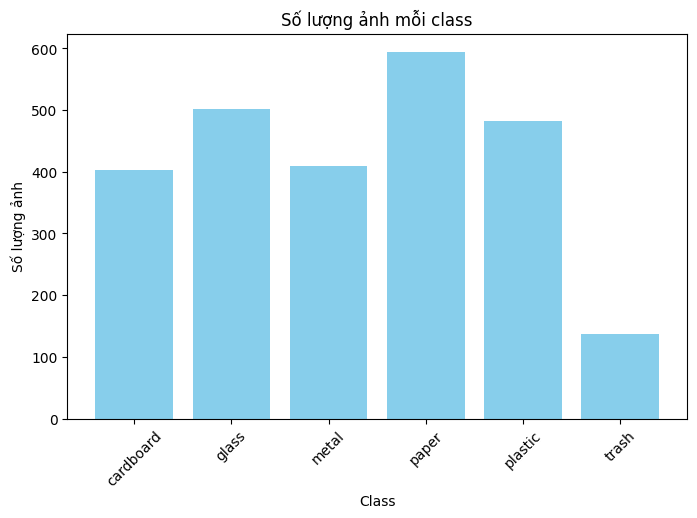

In [ ]:
import matplotlib.pyplot as plt

class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_CLASS_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Số lượng ảnh mỗi class")
plt.xlabel("Class")
plt.ylabel("Số lượng ảnh")
plt.xticks(rotation=45)
plt.show()

### 2.5 Xem ảnh mẫu mỗi class

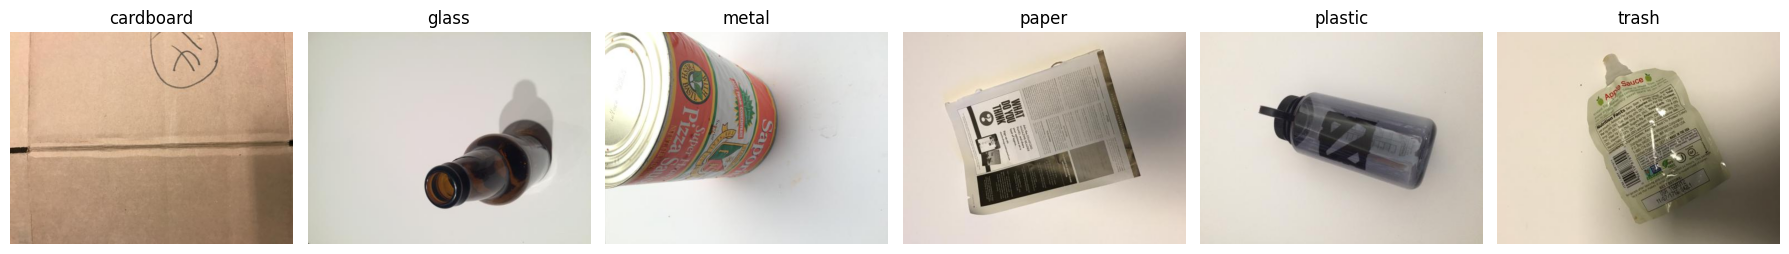

In [ ]:
from PIL import Image

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18,4))
for ax, class_name in zip(axes, CLASS_NAMES):
    class_path = os.path.join(DATA_CLASS_DIR, class_name)
    sample_img = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, sample_img))
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2.6 Kiểm tra kích thước ảnh gốc

In [ ]:
sample_sizes = []
for class_name in CLASS_NAMES[:2]:
    class_path = os.path.join(DATA_CLASS_DIR, class_name)
    for f in os.listdir(class_path)[:5]:
        img = Image.open(os.path.join(class_path, f))
        sample_sizes.append(img.size)
print("Kích thước ảnh mẫu:", sample_sizes)

Kích thước ảnh mẫu: [(512, 384), (512, 384), (512, 384), (512, 384), (512, 384), (512, 384), (512, 384), (512, 384), (512, 384), (512, 384)]


## BƯỚC 3: Tiền xử lý dữ liệu

### 3.1 Chia train/validation/test

In [ ]:
import splitfolders

DATA_SPLIT_DIR = os.path.join(PROJECT_ROOT, "data/train_test_split")

splitfolders.ratio(
    DATA_CLASS_DIR,
    output=DATA_SPLIT_DIR,
    seed=42,          # cố định seed để lần nào chia cũng ra kết quả giống nhau
    ratio=(0.7, 0.15, 0.15)   # train 70%, val 15%, test 15%
)

Copying files: 2527 files [00:37, 68.28 files/s]


In [ ]:
for split in ['train', 'val', 'test']:
    print(f"\n{split}:")
    for cls in CLASS_NAMES:
        path = os.path.join(DATA_SPLIT_DIR, split, cls)
        print(f"  {cls}: {len(os.listdir(path))} ảnh")


train:
  cardboard: 282 ảnh
  glass: 350 ảnh
  metal: 287 ảnh
  paper: 415 ảnh
  plastic: 337 ảnh
  trash: 95 ảnh

val:
  cardboard: 60 ảnh
  glass: 75 ảnh
  metal: 61 ảnh
  paper: 89 ảnh
  plastic: 72 ảnh
  trash: 20 ảnh

test:
  cardboard: 61 ảnh
  glass: 76 ảnh
  metal: 62 ảnh
  paper: 90 ảnh
  plastic: 73 ảnh
  trash: 22 ảnh


### 3.2 Tạo Data Generator (augmentation cho train, chỉ rescale cho val/test)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,          # chuẩn hóa pixel về [0,1]
    rotation_range=30,       # xoay ngẫu nhiên tối đa 30 độ
    width_shift_range=0.2,   # dịch ngang ngẫu nhiên tối đa 20%
    height_shift_range=0.2,  # dịch dọc ngẫu nhiên tối đa 20%
    shear_range=0.15,        # biến dạng cắt (shear) nhẹ
    zoom_range=0.2,          # zoom ngẫu nhiên tối đa 20%
    horizontal_flip=True,    # lật ngang ngẫu nhiên
    fill_mode='nearest'      # cách điền pixel trống sau khi biến đổi
)

val_test_datagen = ImageDataGenerator(rescale=1./255)
# val/test KHÔNG augment — để đánh giá công bằng trên dữ liệu "thật", không bị làm giả

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATA_SPLIT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_SPLIT_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_SPLIT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False   # KHÔNG shuffle — để y_true và y_pred khớp đúng thứ tự khi vẽ confusion matrix
)

Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.


### 3.3 Tính class_weight để xử lý mất cân bằng dữ liệu

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = train_generator.classes
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weight_values))
print(class_weight_dict)

{0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


### 3.4 Lưu lại các thành phần quan trọng của Bước 3 (tránh phải chạy lại nếu mất session)

In [ ]:
import pickle

with open(os.path.join(PROJECT_ROOT, "models/class_weight_dict.pkl"), "wb") as f:
    pickle.dump(class_weight_dict, f)

print("Đã lưu class_weight_dict!")

Đã lưu class_weight_dict!


## BƯỚC 4: Xây dựng và train model baseline

### 4.1 Xây dựng kiến trúc model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,     # bỏ lớp classification gốc của ImageNet (1000 class)
    weights='imagenet'     # dùng trọng số đã học sẵn trên ImageNet
)

base_model.trainable = False   # ĐÓNG BĂNG toàn bộ layer gốc — chỉ train phần thêm mới

x = base_model.output
x = GlobalAveragePooling2D()(x)   # nén feature map thành vector 1 chiều
x = Dense(128, activation='relu')(x)   # layer học đặc trưng riêng cho bài toán rác thải
x = Dropout(0.3)(x)                    # tắt ngẫu nhiên 30% neuron mỗi lần train -> giảm overfitting
output = Dense(len(CLASS_NAMES), activation='softmax')(x)   # output: xác suất cho 6 class

model_baseline = Model(inputs=base_model.input, outputs=output)
model_baseline.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.2 Compile model

In [ ]:
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',   # phù hợp bài toán multi-class, nhãn dạng one-hot
    metrics=['accuracy']
)

### 4.3 Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

PATH_MODEL_BASELINE = os.path.join(PROJECT_ROOT, "models/mobilenetv2_baseline.h5")

callbacks_baseline = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,               # nếu val_loss không cải thiện sau 5 epoch liên tiếp -> dừng
        restore_best_weights=True # tự động khôi phục lại trọng số tốt nhất, không lấy epoch cuối
    ),
    ModelCheckpoint(
        PATH_MODEL_BASELINE,
        monitor='val_accuracy',
        save_best_only=True        # chỉ lưu phiên bản có val_accuracy cao nhất
    )
]

### 4.4 Train model

In [ ]:
history_baseline = model_baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_baseline
)

# Lưu history NGAY sau khi train xong, tránh mất khi ngắt session
with open(os.path.join(PROJECT_ROOT, "models/history_baseline.pkl"), "wb") as f:
    pickle.dump(history_baseline.history, f)

print("Đã lưu model và history baseline!")

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.4095 - loss: 1.5646

56/56 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5572 - loss: 1.1844 - val_accuracy: 0.6976 - val_loss: 0.7888
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7307 - loss: 0.7785

56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 583ms/step - accuracy: 0.7282 - loss: 0.7580 - val_accuracy: 0.8064 - val_loss: 0.5948
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 557ms/step - accuracy: 0.7492 - loss: 0.6807 - val_accuracy: 0.7878 - val_loss: 0.6086
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 563ms/step - accuracy: 0.7899 - loss: 0.5951 - val_accuracy: 0.7984 - val_loss: 0.5780
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.7899 - loss: 0.5099

56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 560ms/step - accuracy: 0.8029 - loss: 0.5002 - val_accuracy: 0.8355 - val_loss: 0.5187
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 553ms/step - accuracy: 0.8199 - loss: 0.4907 - val_accuracy: 0.8064 - val_loss: 0.5717
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 546ms/step - accuracy: 0.8386 - loss: 0.4335 - val_accuracy: 0.8170 - val_loss: 0.5019
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8367 - loss: 0.4166

56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 585ms/step - accuracy: 0.8528 - loss: 0.3904 - val_accuracy: 0.8488 - val_loss: 0.4502
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 543ms/step - accuracy: 0.8698 - loss: 0.3433 - val_accuracy: 0.8355 - val_loss: 0.4809
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 590ms/step - accuracy: 0.8692 - loss: 0.3535 - val_accuracy: 0.8249 - val_loss: 0.5060
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 530ms/step - accuracy: 0.8754 - loss: 0.3207 - val_accuracy: 0.8329 - val_loss: 0.4676
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 562ms/step - accuracy: 0.8732 - loss: 0.3278 - val_accuracy: 0.8223 - val_loss: 0.5221
Epoch 13/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8729 - loss: 0.3384

56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 552ms/step - accuracy: 0.8664 - loss: 0.3316 - val_accuracy: 0.8753 - val_loss: 0.3974
Epoch 14/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 541ms/step - accuracy: 0.8817 - loss: 0.3085 - val_accuracy: 0.8541 - val_loss: 0.4103
Epoch 15/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 515ms/step - accuracy: 0.8930 - loss: 0.2750 - val_accuracy: 0.8462 - val_loss: 0.4548
Epoch 16/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 541ms/step - accuracy: 0.8998 - loss: 0.2597 - val_accuracy: 0.8382 - val_loss: 0.4546
Epoch 17/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 526ms/step - accuracy: 0.8981 - loss: 0.2529 - val_accuracy: 0.8408 - val_loss: 0.4991
Epoch 18/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9240 - loss: 0.2060

56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 521ms/step - accuracy: 0.9168 - loss: 0.2085 - val_accuracy: 0.8806 - val_loss: 0.3733
Epoch 19/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 527ms/step - accuracy: 0.9213 - loss: 0.2260 - val_accuracy: 0.8435 - val_loss: 0.4650
Epoch 20/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 523ms/step - accuracy: 0.9219 - loss: 0.1935 - val_accuracy: 0.8621 - val_loss: 0.4210
Đã lưu model và history baseline!


### 4.5 Vẽ biểu đồ Accuracy/Loss

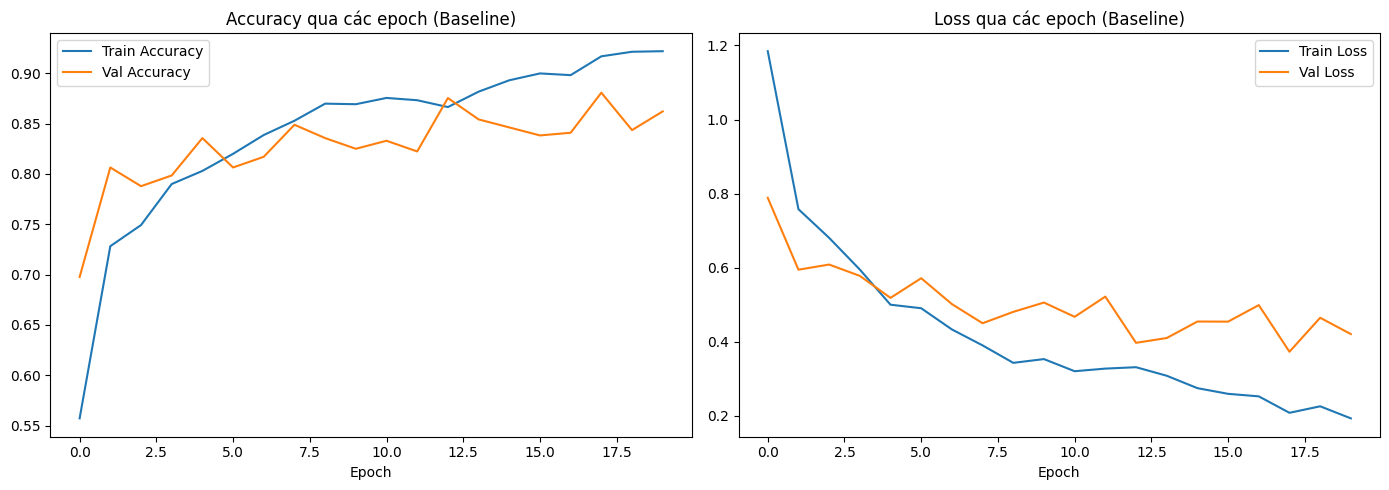

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_baseline.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy qua các epoch (Baseline)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_baseline.history['loss'], label='Train Loss')
axes[1].plot(history_baseline.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss qua các epoch (Baseline)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## BƯỚC 5: Đánh giá model trên tập test

### 5.1 Hàm đánh giá dùng chung (viết 1 lần, dùng lại cho cả baseline và fine-tuned)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def danh_gia_model(model, test_generator, ten_model="Model"):
    """
    Hàm dùng chung để đánh giá 1 model: in test accuracy, vẽ confusion matrix,
    in classification report. Dùng lại được cho cả model_baseline và model_finetuned.
    """
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"[{ten_model}] Test Accuracy: {test_accuracy*100:.2f}% | Test Loss: {test_loss:.4f}")

    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.title(f'Confusion Matrix - {ten_model}')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return y_true, y_pred

### 5.2 Gọi hàm đánh giá cho model baseline

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.8333 - loss: 0.5545
[Baseline] Test Accuracy: 83.33% | Test Loss: 0.5545
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step


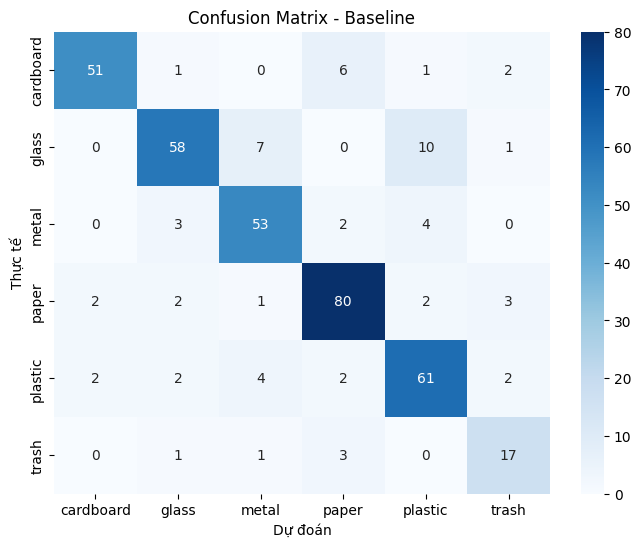

              precision    recall  f1-score   support

   cardboard       0.93      0.84      0.88        61
       glass       0.87      0.76      0.81        76
       metal       0.80      0.85      0.83        62
       paper       0.86      0.89      0.87        90
     plastic       0.78      0.84      0.81        73
       trash       0.68      0.77      0.72        22

    accuracy                           0.83       384
   macro avg       0.82      0.83      0.82       384
weighted avg       0.84      0.83      0.83       384



In [ ]:
y_true_baseline, y_pred_baseline = danh_gia_model(model_baseline, test_generator, "Baseline")

### 5.3 Xem ảnh dự đoán sai (tùy chọn, hay dùng cho slide bảo vệ)

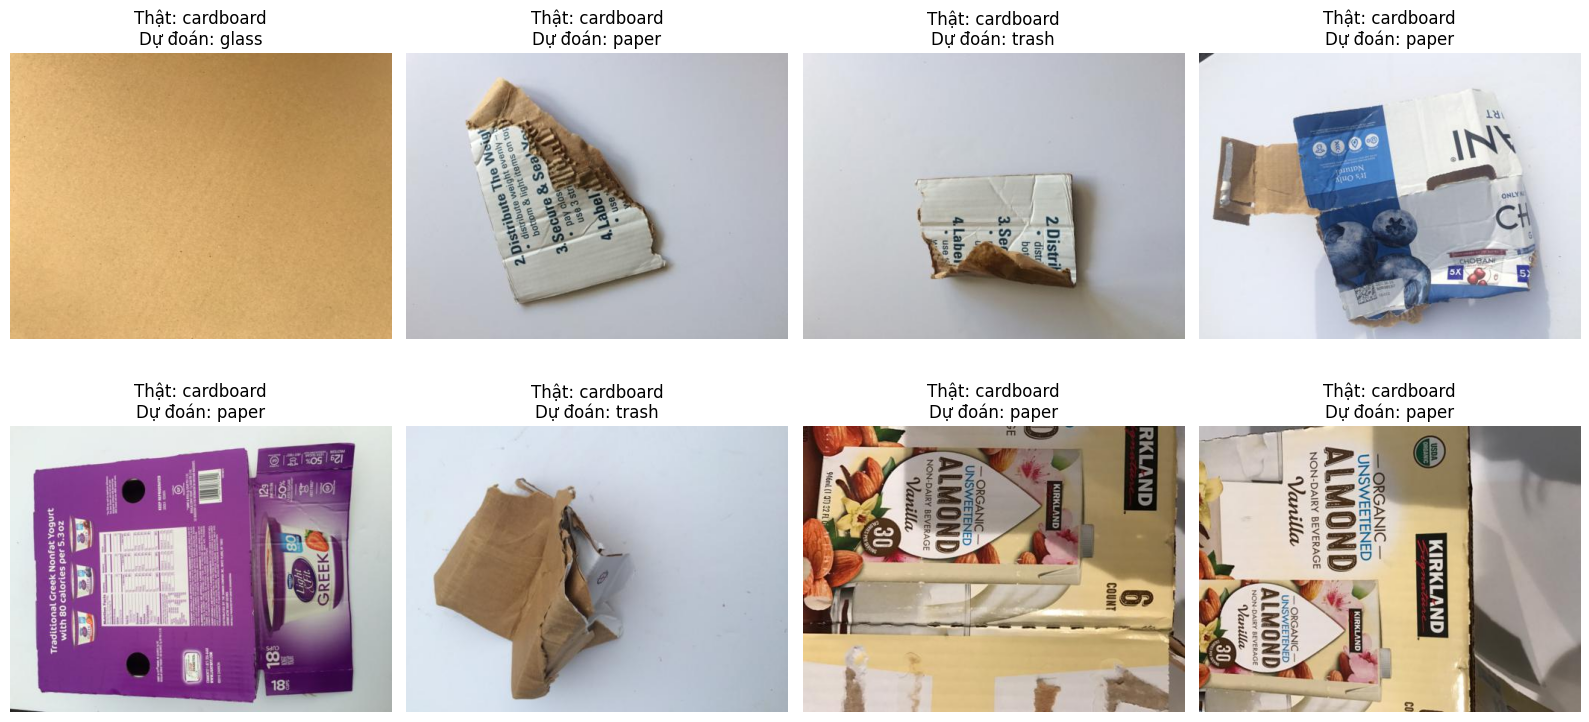

In [ ]:
wrong_idx = np.where(y_pred_baseline != y_true_baseline)[0][:8]

plt.figure(figsize=(16,8))
for i, idx in enumerate(wrong_idx):
    img_path = test_generator.filepaths[idx]
    img = plt.imread(img_path)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(f"Thật: {CLASS_NAMES[y_true_baseline[idx]]}\nDự đoán: {CLASS_NAMES[y_pred_baseline[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## BƯỚC 6: Fine-tuning

### 6.1 Load lại model baseline (đảm bảo bắt đầu đúng điểm xuất phát)


In [ ]:
model_finetuned = tf.keras.models.load_model(PATH_MODEL_BASELINE)

### 6.2 Unfreeze một số layer cuối


**Lưu ý quan trọng:** vì model được xây bằng Functional API kiểu `Model(inputs=base_model.input, outputs=output)`, Keras sẽ **làm phẳng** toàn bộ layer của MobileNetV2 vào chung danh sách `model_finetuned.layers` — không giữ `base_model` như 1 layer/khối riêng. Vậy `model_finetuned.layers[0]` chỉ là `InputLayer`, không có thuộc tính `.layers` (đây là lỗi `AttributeError` hay gặp). Cách đúng là dựa vào việc biết chính xác 4 layer cuối cùng là phần tự thêm vào (`GlobalAveragePooling2D`, `Dense(128)`, `Dropout`, `Dense(output)`):

In [ ]:
print("Tổng số layer:", len(model_finetuned.layers))

# 4 layer cuối luôn là phần tự thêm (GAP, Dense128, Dropout, Dense output)
# -> mọi layer TRƯỚC đó chính là các layer gốc của MobileNetV2
base_model_layers = model_finetuned.layers[:-4]

fine_tune_at = 100   # MobileNetV2 có khoảng 155 layer; giữ đóng băng 100 layer đầu (đặc trưng cơ bản)

# Đóng băng toàn bộ layer gốc trước
for layer in base_model_layers:
    layer.trainable = False

# Mở lại (unfreeze) các layer từ vị trí fine_tune_at trở đi
for layer in base_model_layers[fine_tune_at:]:
    layer.trainable = True

# Đảm bảo 4 layer mới thêm luôn được train
for layer in model_finetuned.layers[-4:]:
    layer.trainable = True

trainable_count = sum([1 for layer in model_finetuned.layers if layer.trainable])
print(f"Số layer đang trainable: {trainable_count}/{len(model_finetuned.layers)}")

Tổng số layer: 158
Số layer đang trainable: 58/158


### 6.3 Compile lại với learning rate nhỏ hơn nhiều

In [ ]:
model_finetuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # nhỏ hơn baseline 100 lần
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

- Learning rate phải rất nhỏ khi fine-tune, vì nếu để lớn như baseline, gradient sẽ "phá hỏng" các trọng số ImageNet đã học tốt từ trước.

### 6.4 Điều chỉnh nhẹ class_weight cho trash

In [ ]:
class_weight_dict_adjusted = class_weight_dict.copy()
class_weight_dict_adjusted[CLASS_NAMES.index('trash')] *= 0.7   # giảm 30% trọng số của trash
print(class_weight_dict_adjusted)

{0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(2.1687719298245614)}


- Lý do: ở baseline, `trash` có weight quá cao (~3.09) khiến model "đoán bừa" trash quá nhiều (precision thấp, 0.51). Giảm nhẹ weight giúp cân bằng lại giữa precision và recall.

### 6.5 Callbacks và train fine-tuning

In [ ]:
PATH_MODEL_FINETUNED = os.path.join(PROJECT_ROOT, "models/mobilenetv2_finetuned.h5")

callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(PATH_MODEL_FINETUNED, monitor='val_accuracy', save_best_only=True)
]

history_finetune = model_finetuned.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight_dict_adjusted,
    callbacks=callbacks_finetune
)

# Lưu history NGAY LẬP TỨC
with open(os.path.join(PROJECT_ROOT, "models/history_finetune.pkl"), "wb") as f:
    pickle.dump(history_finetune.history, f)

print("Đã lưu model và history fine-tuned!")

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.6562 - loss: 1.2175

56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 921ms/step - accuracy: 0.6874 - loss: 1.0439 - val_accuracy: 0.8780 - val_loss: 0.4048
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 534ms/step - accuracy: 0.7395 - loss: 0.6856 - val_accuracy: 0.8568 - val_loss: 0.4413
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 554ms/step - accuracy: 0.7933 - loss: 0.5290 - val_accuracy: 0.8594 - val_loss: 0.4524
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 541ms/step - accuracy: 0.8035 - loss: 0.4940 - val_accuracy: 0.8621 - val_loss: 0.4518
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 529ms/step - accuracy: 0.8381 - loss: 0.4257 - val_accuracy: 0.8621 - val_loss: 0.4504
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 511ms/step - accuracy: 0.8471 - loss: 0.4042 - val_accuracy: 0.8594 - val_loss: 0.4471
Đã lưu model và history fine-tuned!


### 6.6 Vẽ biểu đồ Accuracy/Loss cho fine-tuned model

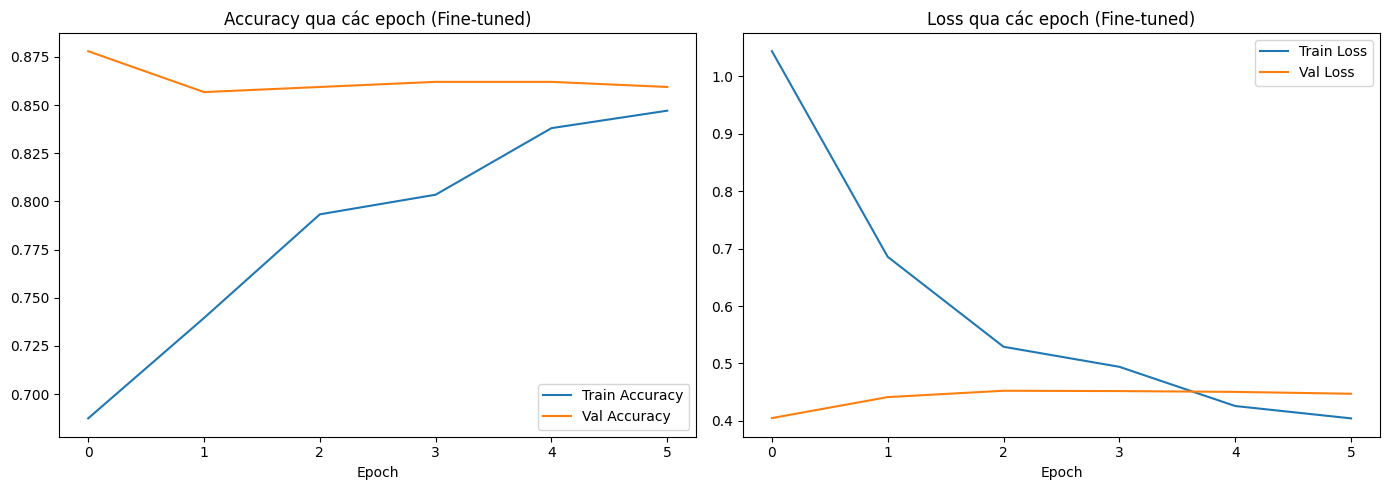

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_finetune.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy qua các epoch (Fine-tuned)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_finetune.history['loss'], label='Train Loss')
axes[1].plot(history_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss qua các epoch (Fine-tuned)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

6.7 Đánh giá fine-tuned model (dùng lại hàm ở Bước 5.1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.8255 - loss: 0.5741
[Fine-tuned] Test Accuracy: 82.55% | Test Loss: 0.5741
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step


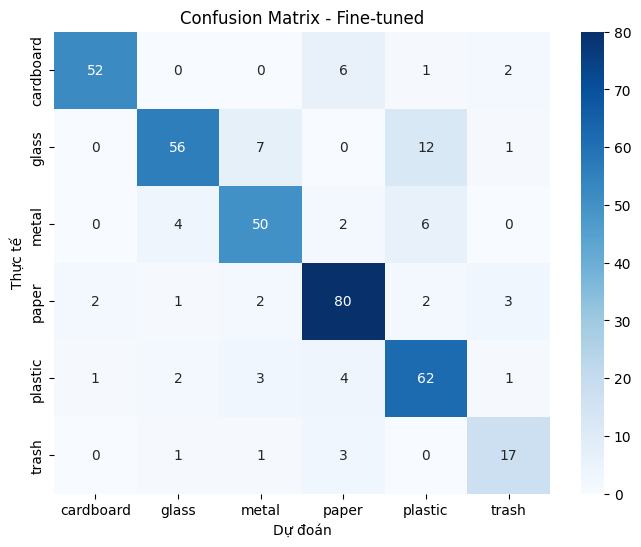

              precision    recall  f1-score   support

   cardboard       0.95      0.85      0.90        61
       glass       0.88      0.74      0.80        76
       metal       0.79      0.81      0.80        62
       paper       0.84      0.89      0.86        90
     plastic       0.75      0.85      0.79        73
       trash       0.71      0.77      0.74        22

    accuracy                           0.83       384
   macro avg       0.82      0.82      0.82       384
weighted avg       0.83      0.83      0.83       384



In [ ]:
y_true_finetuned, y_pred_finetuned = danh_gia_model(model_finetuned, test_generator, "Fine-tuned")